# PHASE 1 PROJECT

# AIRCRAFT RISK EVALUATION

# OVERVIEW

Our company is expanding in to new industries to diversify its portfolio. The company is interested in purchasing and operating airplanes for commercial and private enterprise  which will be a key step in our growth strategy. To align this expansion with our strategic goals, we will rely on data-driven insights to inform our decisions. A thorough risk assessment will be conducted using aviation accident data spanning from 1993 to 2023. The analysis aims to identify aircraft models and makes the a higher likelihood of severe accidents or operational failures, determine locations that pose higher risks for aircraft operations,assess the optimal number of engines required for stable and safe flights and and analyze the Total fatal injuries by the purpose of flight.

## BUSINESS QUESTIONS
  1. Which flight operations have the highest risk of fatal injuries?
  2. What aircraft is safer and less likely to get accidents?
  3. Which are the locations safe for aircraft navigation?
  4. What are the optimal number of engines sufficient for ensuring the stability and safety of aircraft operations?

## BUSINESS UNDERSTANDING
Our company is expanding into the aviation industry, seeking to purchase and operate aircraft for both commercial and private enterprises. To ensure this venture is both safe , we need to assess the risks associated with different aircraft models, operational environments, and structural designs. Specifically, the objectives of this analysis are :
1. Analyze the Total fatal injuries by the purpose of flight

2. Identify aircraft models and makes with a higher likelihood of severe accidents or operational failures.

3. Investigate for the locations that have historically proven risky for aircraft operations, highlighting potential geographic safety concerns.

4. Determine the number of engines sufficient for ensuring the stability and safety of aircraft operations.

By achieving these objectives, we will be able to select aircraft models and operational strategies that align with the company’s goals of safety and  reliability minimizing potential risks as we enter this new industry.

## DATA UNDERSTANDING.
The NTSB aviation accident database contains information from 1962 and later about civil aviation accidents and selected incidents within the United States, its territories and possessions, and in international waters. This dataset drawn from kaggle initially had 31 columns and 88889 rows.The dataset provides insights into trends of accidents and incidents across different aircraft types , locations  among other key attributes. This dataset is important for investigating safety concerns,potential areas for risk mitigation in aviation operations.

## DATA CLEANING:
The Python libaries imported for analysis were matplotlib,pandas and numpy. The data was cleaned using the Visual Studio code editor.Below were the steps followed for data cleaning

  -Importing the relevant python libraries.
  -Loading and reading the CSV file.
  -Inspecting and understanding the data.
  -Data Cleaning.
  -Checked for erroneous values
  -Dropped all the irrelevant columns and those that had alot of missing values
  -Filled in  the missing values for both the numerical columns  and categorical columns.
  -Then we stripped all the white spaces.
  -Removed the '.' in the column names and replaced with '_'
  -Added a few other columns
  -Finally exported the cleaned data to a new csv file called Aviation_cleaned.csv

In [108]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


## Data Loading and Inspection

Below is a function to load  the data and display the first five rows of the dataset

In [109]:
def load_and_display_data(filepath):
    df = pd.read_csv(filepath, encoding='latin-1')
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    return df

In [110]:
df = load_and_display_data("AviationData.csv")

Dataset shape: 88889 rows, 31 columns

First 5 rows of the dataset:


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


Below is a function to check the data set information
```python

In [111]:
def check_dataset_info(df):
    """
    Display comprehensive information about the dataset including:
    - Summary statistics
    - Dataset info (data types, non-null counts)
    - Column names and details
    """
    
    print("=" * 50)
    print("DATASET INFORMATION")
    print("=" * 50)
    
    # 1. Display summary statistics
    print("\n1. SUMMARY STATISTICS:")
    print("-" * 30)
    print(df.describe(include='all'))
    
    # 2. Display dataset info
    print("\n2. DATASET INFO:")
    print("-" * 30)
    df.info()
    
    # 3. Display column information
    print("\n3. COLUMN DETAILS:")
    print("-" * 30)
    print(f"Total columns: {len(df.columns)}")
    print("\nColumn names and data types:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col:<25} ({df[col].dtype})")

In [112]:
check_dataset_info(df)

DATASET INFORMATION

1. SUMMARY STATISTICS:
------------------------------
              Event.Id Investigation.Type Accident.Number  Event.Date  \
count            88889              88889           88889       88889   
unique           87951                  2           88863       14782   
top     20001212X19172           Accident      CEN22LA149  1984-06-30   
freq                 3              85015               2          25   
mean               NaN                NaN             NaN         NaN   
std                NaN                NaN             NaN         NaN   
min                NaN                NaN             NaN         NaN   
25%                NaN                NaN             NaN         NaN   
50%                NaN                NaN             NaN         NaN   
75%                NaN                NaN             NaN         NaN   
max                NaN                NaN             NaN         NaN   

             Location        Country Latitude Lo

Below is a function used to check and display the percentage of the missing and the duplicate values in the dataset
```python

In [113]:
def check_missing_duplicates(df):
    
    print("=" * 50)
    print("MISSING VALUES & DUPLICATES ANALYSIS")
    print("=" * 50)
    
    # Check for missing values
    print("\n1. MISSING VALUES:")
    print("-" * 30)
    
    missing_count = df.isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Missing_Count': missing_count,
        'Missing_Percent': missing_percent.round(2)
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0]
    
    if len(missing_df) > 0:
        print("Columns with missing values:")
        print(missing_df.sort_values('Missing_Percent', ascending=False))
        print(f"\nTotal missing values in dataset: {df.isnull().sum().sum()}")
    else:
        print("No missing values found in the dataset.")
    
    # Check for duplicates
    print("\n2. DUPLICATE ROWS:")
    print("-" * 30)
    
    duplicate_count = df.duplicated().sum()
    duplicate_percent = (duplicate_count / len(df)) * 100
    
    print(f"Number of duplicate rows: {duplicate_count}")
    print(f"Percentage of duplicate rows: {duplicate_percent:.2f}%")
    
    if duplicate_count > 0:
        print("\nSample duplicate rows:")
        print(df[df.duplicated(keep=False)].head())
    
    return missing_df

In [114]:
missing_stats = check_missing_duplicates(df)

MISSING VALUES & DUPLICATES ANALYSIS

1. MISSING VALUES:
------------------------------
Columns with missing values:
                        Missing_Count  Missing_Percent
Schedule                        76307            85.85
Air.carrier                     72241            81.27
FAR.Description                 56866            63.97
Aircraft.Category               56602            63.68
Longitude                       54516            61.33
Latitude                        54507            61.32
Airport.Code                    38757            43.60
Airport.Name                    36185            40.71
Broad.phase.of.flight           27165            30.56
Publication.Date                13771            15.49
Total.Serious.Injuries          12510            14.07
Total.Minor.Injuries            11933            13.42
Total.Fatal.Injuries            11401            12.83
Engine.Type                      7096             7.98
Report.Status                    6384             7.18
Pur

In [115]:
def drop_features(df, features_to_drop):
    
    print("=" * 50)
    print("FEATURE DROPPING")
    print("=" * 50)
    
    # Convert single feature to list for consistent processing
    if isinstance(features_to_drop, str):
        features_to_drop = [features_to_drop]
    
    # Check which features actually exist in the DataFrame
    existing_features = [feature for feature in features_to_drop if feature in df.columns]
    non_existing_features = [feature for feature in features_to_drop if feature not in df.columns]
    
    # Print information about the operation
    print(f"Features requested to drop: {features_to_drop}")
    print(f"Features found in DataFrame: {existing_features}")
    
    if non_existing_features:
        print(f"Warning: These features were not found in the DataFrame: {non_existing_features}")
    
    if not existing_features:
        print("No valid features to drop. Returning original DataFrame.")
        return df
    
    # Create copy of DataFrame to avoid modifying the original
    df_dropped = df.copy()
    
    # Store original shape
    original_shape = df_dropped.shape
    
    # Drop the features
    df_dropped = df_dropped.drop(columns=existing_features)
    
    # Print results
    print(f"\nOriginal DataFrame shape: {original_shape}")
    print(f"New DataFrame shape: {df_dropped.shape}")
    print(f"Successfully dropped {len(existing_features)} features")
    print(f"\nRemaining features: {list(df_dropped.columns)}")
    
    return df_dropped


In [144]:
df_copy = df.copy
# Drop specific features
df= drop_features(df, ['Aircraft.Category', 'Registration.Number','FAR.Description', 'Schedule', 'Air.carrier', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name'])

FEATURE DROPPING
Features requested to drop: ['Aircraft.Category', 'Registration.Number', 'FAR.Description', 'Schedule', 'Air.carrier', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name']
Features found in DataFrame: []
No valid features to drop. Returning original DataFrame.


In [117]:
# We  use the str.strip function  to strip the leading and trailing spaces on the columns
df.columns = df.columns.str.strip()

# Replace the '.' with '_' in the feature names 
df.columns = df.columns.str.replace('.', '_', regex=False)
df.columns

Index(['Event_Id', 'Investigation_Type', 'Accident_Number', 'Event_Date',
       'Location', 'Country', 'Injury_Severity', 'Aircraft_damage', 'Make',
       'Model', 'Amateur_Built', 'Number_of_Engines', 'Engine_Type',
       'Purpose_of_flight', 'Total_Fatal_Injuries', 'Total_Serious_Injuries',
       'Total_Minor_Injuries', 'Total_Uninjured', 'Weather_Condition',
       'Broad_phase_of_flight', 'Report_Status', 'Publication_Date'],
      dtype='object')

In [118]:
#Removing the double entries from the  Make column and making all of them to be in  lower case.
df['Make'] = df['Make'].str.title()

In [119]:
#format Event.Date column 
df['Event_Date'] = pd.to_datetime(df['Event_Date'], format='%Y-%m-%d')


In [120]:
#check for the remaining numerical columns 
numerical_columns = df.select_dtypes(include=['number']).columns
print(numerical_columns)

Index(['Number_of_Engines', 'Total_Fatal_Injuries', 'Total_Serious_Injuries',
       'Total_Minor_Injuries', 'Total_Uninjured'],
      dtype='object')


In [121]:
#First  check for the remaining categorical columns.
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print(categorical_columns)

Index(['Event_Id', 'Investigation_Type', 'Accident_Number', 'Location',
       'Country', 'Injury_Severity', 'Aircraft_damage', 'Make', 'Model',
       'Amateur_Built', 'Engine_Type', 'Purpose_of_flight',
       'Weather_Condition', 'Broad_phase_of_flight', 'Report_Status',
       'Publication_Date'],
      dtype='object')


In [122]:
# Fill missing values for numerical features with median
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing values for categorical features with "unknown"
for col in categorical_columns:
    df[col] = df[col].fillna("unknown")

print("Missing values have been filled:")
print("- Numerical features filled with median")
print("- Categorical features filled with 'unknown'")

Missing values have been filled:
- Numerical features filled with median
- Categorical features filled with 'unknown'


In [123]:
# check to see if there are any other missing
df.isna().sum()

Event_Id                  0
Investigation_Type        0
Accident_Number           0
Event_Date                0
Location                  0
Country                   0
Injury_Severity           0
Aircraft_damage           0
Make                      0
Model                     0
Amateur_Built             0
Number_of_Engines         0
Engine_Type               0
Purpose_of_flight         0
Total_Fatal_Injuries      0
Total_Serious_Injuries    0
Total_Minor_Injuries      0
Total_Uninjured           0
Weather_Condition         0
Broad_phase_of_flight     0
Report_Status             0
Publication_Date          0
dtype: int64

We create a new column Accident_Numbers which will contain 1 for rows where the investigation type is 'Accident' and 0 for rows where it's anything else (like 'Incident')

In [124]:

df['Accident_Codes'] = df['Investigation_Type'].apply(lambda x: 1 if x == 'Accident' else 0)

# Verify the new column
df[['Investigation_Type', 'Accident_Codes']].head()

,Investigation_Type,Accident_Codes
0,Accident,1
1,Accident,1
2,Accident,1
3,Accident,1
4,Accident,1


In the cell below decimal values in the 'Number_of_Engines' column are rounded off and a new column called `Engine_Categories` is created with the rounded values.A  dictionary called **`engine_mapping`** is then used to map the numerical engine values (e.g., 0, 1, 2) to their corresponding word representations (e.g., 'Zero', 'One', 'Two'). The **`Engine_Categories`** column is updated with these word values, and the final step prints the first few rows of the DataFrame, showing both the original engine numbers and their corresponding word categories.

In [125]:
# Round off the decimal values in 'Number_of_Engines'
df['Engine_Categories'] = df['Number_of_Engines'].round()

# Step 2: Create a mapping of numbers to words
engine_mapping = {
    0: 'Zero',
    1: 'One',
    2: 'Two',
    3: 'Three',
    4: 'Four',
    6: 'Six',
    8: 'Eight'
}

# Map the rounded engine numbers to words in the same column
df['Engine_Categories'] = df['Engine_Categories'].map(engine_mapping)
print(df[['Number_of_Engines', 'Engine_Categories']].head())



   Number_of_Engines Engine_Categories
0                1.0               One
1                1.0               One
2                1.0               One
3                1.0               One
4                1.0               One


In [126]:
# Confirming that the new columns are created
df.shape

(88889, 24)

##### We now save the cleaned data to a csv file

In [102]:
df.to_csv('Aviation_cleaned.csv',index = False)

##  Exploratory Data Analysis

#####  In this section we are using visualizations to address the objectives we listed earlier. 

In [127]:
df1 = df.copy()

In [145]:
df1.head()

,Event_Id,Investigation_Type,Accident_Number,Event_Date,Location,Country,Injury_Severity,Aircraft_damage,Make,Model,...,Total_Fatal_Injuries,Total_Serious_Injuries,Total_Minor_Injuries,Total_Uninjured,Weather_Condition,Broad_phase_of_flight,Report_Status,Publication_Date,Accident_Codes,Engine_Categories
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,Fatal(2),Destroyed,Stinson,108-3,...,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,unknown,1,One
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,Fatal(4),Destroyed,Piper,PA24-180,...,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996,1,One
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,Fatal(3),Destroyed,Cessna,172M,...,3.0,0.0,0.0,1.0,IMC,Cruise,Probable Cause,26-02-2007,1,One
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,Fatal(2),Destroyed,Rockwell,112,...,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,1,One
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,Fatal(1),Destroyed,Cessna,501,...,1.0,2.0,0.0,0.0,VMC,Approach,Probable Cause,16-04-1980,1,One


We will first do a graphical representation in a pie chart of the Investigation_Type column to be able to know the relative percentages of the two possibilities(Accident and Incident)

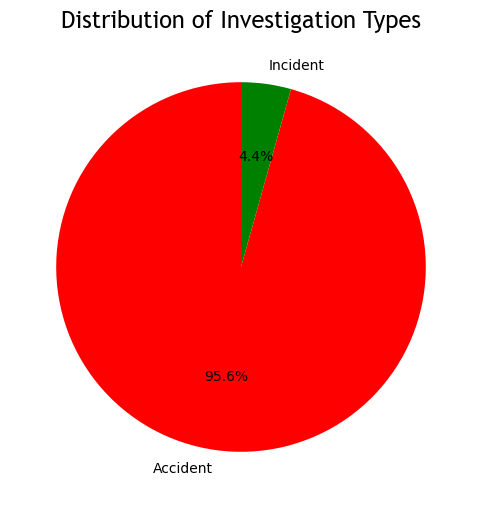

In [ ]:

investigation_type_counts = df1['Investigation_Type'].value_counts()
# Create the pie chart
plt.figure(figsize=(6, 6),facecolor='white')
plt.pie(investigation_type_counts, 
        labels=investigation_type_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['r', 'g'])

# Title for the chart
plt.title('Distribution of Investigation Types',fontname='Trebuchet Ms',fontsize=17)

# Show the pie chart
plt.show()


From the graphical representation above we can see that the accidents takes 95.6% of the investigation done while the incidences take 4.4% .

Which flight operations have the highest risk of fatal injuries?

In [129]:
# Group by 'Purpose_of_flight' and sum 'Total_Fatal_Injuries'
fatal_by_purpose = df1.groupby('Purpose_of_flight')['Total_Fatal_Injuries'].sum()

# Remove the 'Unknown' flight purpose
fatal_injuries_by_purpose = fatal_by_purpose[fatal_by_purpose.index != 'Unknown']

# Sort the values in descending order and select the top ten
top_10_fatal = fatal_injuries_by_purpose.sort_values(ascending=False).head(10)

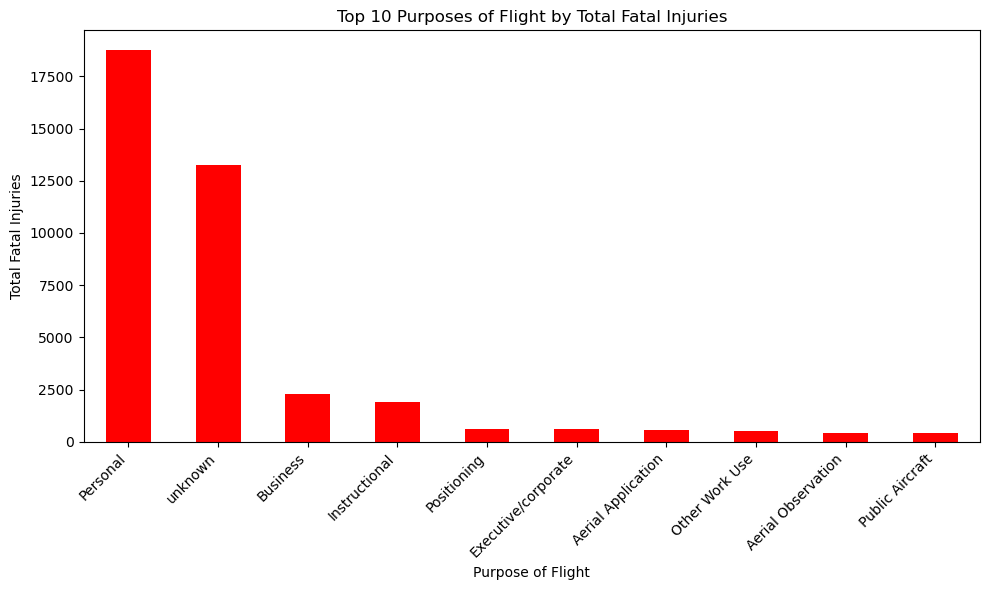

In [131]:

# Plotting the data
plt.figure(figsize=(10, 6))
top_10_fatal.plot(kind='bar', color='red')
plt.title('Top 10 Purposes of Flight by Total Fatal Injuries')
plt.ylabel('Total Fatal Injuries')
plt.xlabel('Purpose of Flight')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From the above figure we can see the personal flight purpose is more prone to fatal accidents.

Which are the top 10 aircraft models and makes with a high likelihood of  accidents? 

In [143]:
#filter the df1 DataFrame to include only rows where the InvestigationType column has the value 'Accident'.
Accidents = df1[df1['Investigation_Type'] == 'Accident']
Make_Accidents = Accidents.groupby('Make').size().sort_values(ascending=False)
Model_Accidents = Accidents.groupby('Model').size().sort_values(ascending=False)
# We now print the top 15 Aircrafts with the most accident occurences both the model and the make
print(f'The top 10 Aircraft Makes with the most accident occurences:\n{Make_Accidents.head(10)}\n\n\n')
print(f'Top 10 Aircraft Models with the most accident occurences:\n{Model_Accidents.head(10)}\n\n\n')

The top 10 Aircraft Makes with the most accident occurences:
Make
Cessna      26793
Piper       14684
Beech        5177
Bell         2662
Boeing       1362
Mooney       1311
Robinson     1219
Grumman      1158
Bellanca     1040
Hughes        925
dtype: int64



Top 10 Aircraft Models with the most accident occurences:
Model
152          2349
172          1747
172N         1161
PA-28-140     929
150           822
172M          793
172P          685
182           653
180           621
150M          583
dtype: int64





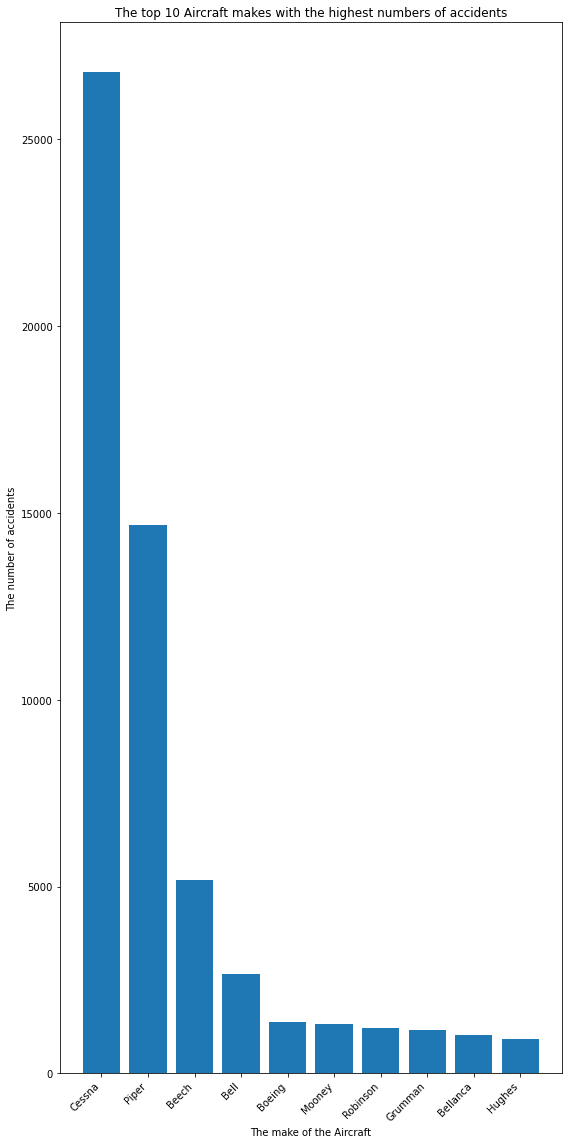

In [67]:
fig, ax = plt.subplots(figsize=(8, 16))

# Use Make_Accidents for x-axis and its values for height
x = Make_Accidents.head(10).index  # Extract the labels (Make names)
height = Make_Accidents.head(10).values  # Extract the corresponding values (number of accidents)

ax.bar(x, height)
ax.set_xlabel('The make of the Aircraft')  # Fixed method name
ax.set_ylabel('The number of accidents')  # Fixed method name
ax.set_title('The top 10 Aircraft makes with the highest numbers of accidents')

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()

From the figure plotted above it can be clearly seen that cessna and piper make aircrafts have the highest incidences of accidents.

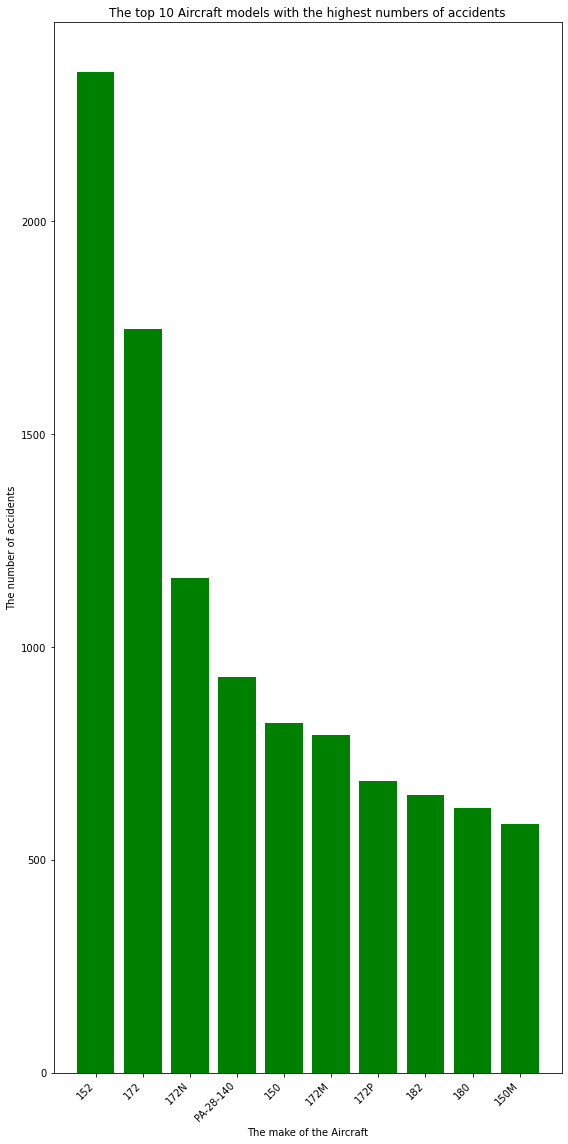

In [ ]:
fig, ax = plt.subplots(figsize=(8, 16))

# Use Make_Accidents for x-axis and its values for height
x = Model_Accidents.head(10).index  # Extract the labels (Make names)
height = Model_Accidents.head(10).values  # Extract the corresponding values (number of accidents)

ax.bar(x, height,color='green',)
ax.set_xlabel('The make of the Aircraft')  
ax.set_ylabel('The number of accidents')  
ax.set_title('The top 10 Aircraft models with the highest numbers of accidents')

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()

From the figure plotted above it can be clearly see that 152 and 172 model aircrafts have  high  incidences of accidents.

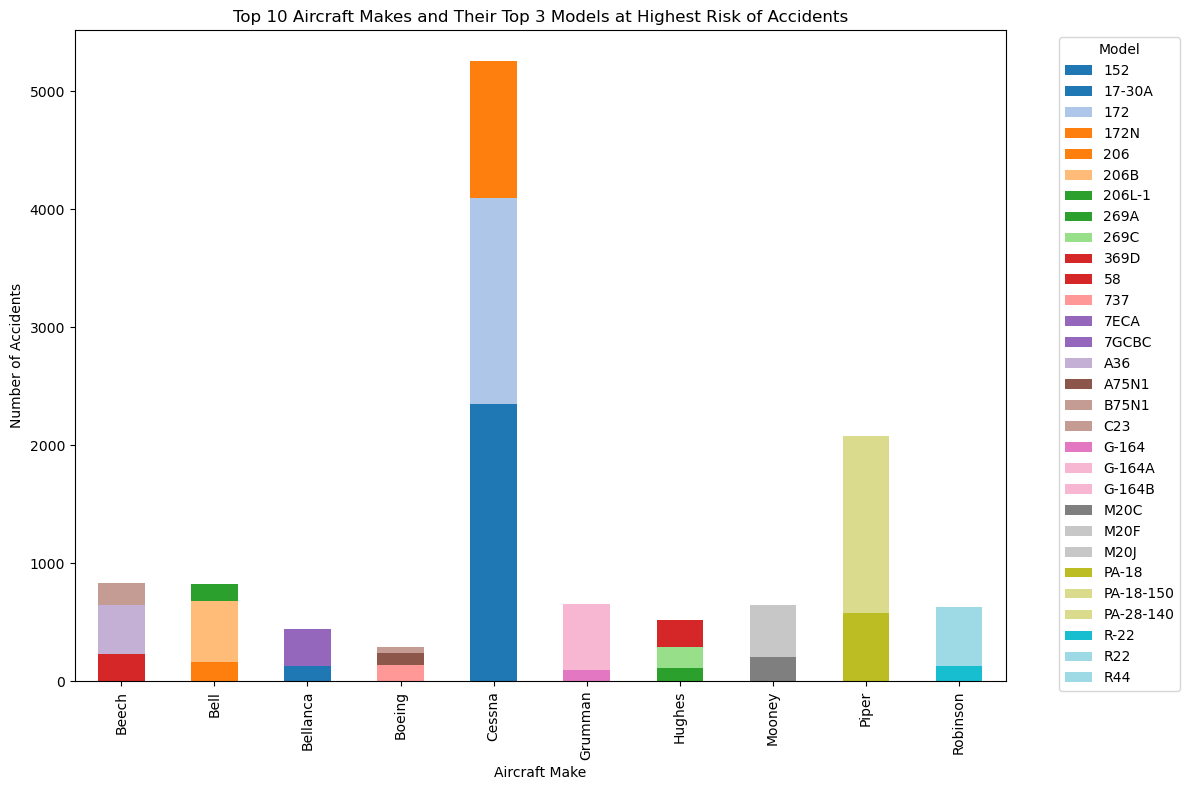

In [ ]:
# top 10 makes and their top 3 models by accident count
top_makes = Make_Accidents.head(10).index
stacked_data = Accidents[Accidents['Make'].isin(top_makes)]

# For each make, get top 3 models by accident count
stacked_counts = (
    stacked_data.groupby(['Make', 'Model'])
    .size()
    .groupby(level=0, group_keys=False)
    .nlargest(3)
    .reset_index(name='Accident_Count')
)

# Pivot for stacked bar chart
pivot_df = stacked_counts.pivot(index='Make', columns='Model', values='Accident_Count').fillna(0)

# Plot stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')
plt.title('Top 10 Aircraft Makes and Their Top 3 Models at Highest Risk of Accidents')
plt.xlabel('Aircraft Make')
plt.ylabel('Number of Accidents')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The figure above  shows that the cessna make,followed by piper aircrafts have high incidences of accidents across different models.


Which are the locations safe for aircraft navigation?


In [136]:
# Analysing  the number of accidents per location using the groupby function 
Accidents_location = df1.groupby('Location').size().sort_values(ascending=False).head(10)
Accidents_location


Location
ANCHORAGE, AK      434
MIAMI, FL          200
ALBUQUERQUE, NM    196
HOUSTON, TX        193
CHICAGO, IL        184
FAIRBANKS, AK      174
TUCSON, AZ         142
PHOENIX, AZ        132
ORLANDO, FL        132
ENGLEWOOD, CO      131
dtype: int64

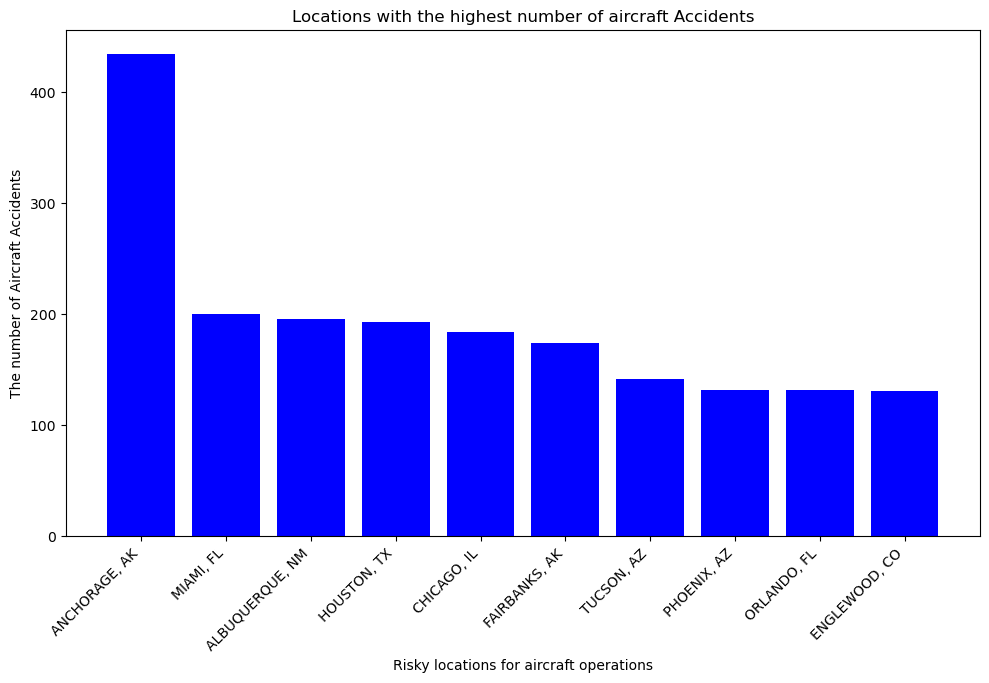

In [140]:
fig, ax = plt.subplots(figsize = (10, 6))
x = Accidents_location.index
heights = Accidents_location.values

bar_title ='Locations with the highest number of aircraft Accidents'
bar_count_label = 'The number of Aircraft Accidents'
bar_series_label = 'Risky locations for aircraft operations'

ax.bar(x, heights,color = 'b')
ax.set_xlabel(bar_series_label)
ax.set_ylabel(bar_count_label)
ax.set_title(bar_title)

plt.tight_layout()
plt.xticks(rotation=45, ha='right') 
plt.show()

The figure above shows Anchorage being the most risky location for aircraft operations and Phoenix and Englewood being among the locations safer for aircraft operations.

How many engines are sufficient for ensuring the stability and safety of aircraft operations?

In [71]:
df1['Number_of_Engines'].value_counts()

1.000000    69582
2.000000    11079
1.146585     6084
0.000000     1226
3.000000      483
4.000000      431
8.000000        3
6.000000        1
Name: Number_of_Engines, dtype: int64

In [141]:
# Analysis of number of accidents by number of engines Number.of.Engines,  Engine.Type
Engine_Accidents = pd.pivot_table(df1,index='Number_of_Engines',values=['Investigation_Type'],aggfunc=np.size).reset_index()
Engine_Accidents

,Number_of_Engines,Investigation_Type
0,0.0,1226
1,1.0,75666
2,2.0,11079
3,3.0,483
4,4.0,431
5,6.0,1
6,8.0,3


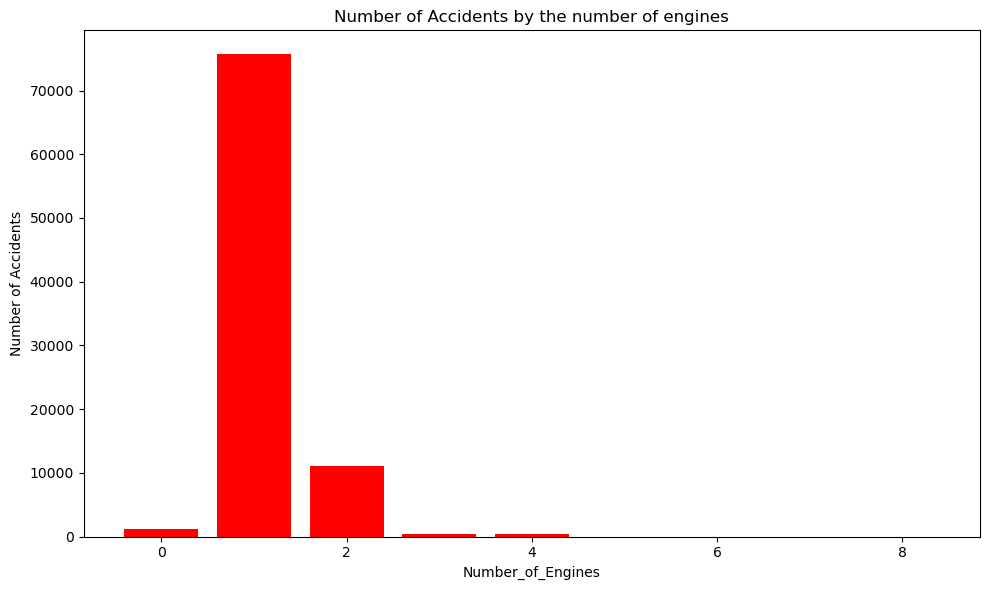

In [142]:
fig, ax = plt.subplots(figsize=(10,6))
x = Engine_Accidents['Number_of_Engines']
y = Engine_Accidents['Investigation_Type']
ax.bar(x, y, color='r')  # Use 'y' for the height of the bars
ax.set_xlabel('Number_of_Engines')  # Call set_xlabel as a function
ax.set_ylabel('Number of Accidents')  # Call set_ylabel as a function
ax.set_title('Number of Accidents by the number of engines')
plt.tight_layout()

The Aircrafts with more than 4 engines have lesser occurrences of accidents meaning those aircrafts with less than four engines have a greater probability of accidents.

## Findings

From the graphical representation above we can see that the accidents takes 95.6% of the investigation done while the incidences take 4.4% of the investigation done.

1. The personal flight purpose is more prone to fatal accidents with a total of 18762 Total Fatal injuries.

2. We can conclude that the Model with the most accident occurences is the 152 model with 2348 number of accidents  followed by 172 model with 1744 number of accidents.

3. We can also conclude that the Make with the most accident occurences is Cessna  with 26793 number of accidents  followed by Piper with 14684 number of accidents.


4. Anchorage is  the most risky location for aircraft operations while Orlando and Chicago are among the locations safer for aircraft operations.

5. The cessna make,followed by piper aircrafts have high incidences of accidents across different models.

6. We can see that the aircrafts with more than 4 engines have lesser occurrences of accidents. This would also mean that the aircrafts with less than four engines have a greater probability of accidents.


## Conclusions
1. The personal flight purpose is more prone to fatal accidents.

2. The aircraft model with the highest number of accidents is the 152 model, followed by the 172 model.

3. In terms of aircraft make, Cessna has the most accident occurrences, followed by Piper. Geographically, Anchorage is identified as the riskiest location for aircraft operations, while Orlando and Chicago are comparatively safer.

4. Aircraft with more than four engines show fewer accidents, suggesting that opting for planes with four or more engines may reduce the likelihood of accidents.


## Recommendations
1. Prioritize and focus on the commercial and business flight operations where regulatory oversight and safety protocols must exist.
   
2. Avoid aircraft makes and models that have high accident rates, including brands like Cessna and Piper.
   
3. Locations with a high risk of accidents should be avoided. This can help airlines to ensure the stability and safety of their aircraft operations.

4. Opting for aircraft with four or more engines, which is considered the optimal number for stable and safe flights, can help minimize the risk of accidents.
